# Notebook 4: Traffic Speed Prediction with Deep Learning & Advanced Methods
# Dataset: METR-LA from HuggingFac

### 1. Import Libraries


In [2]:
!pip install -q ipympl mpld3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 66.5 MB/s eta 0:00:00


In [8]:
!pip install -q ipympl bokeh mpld3 scikit-learn

In [9]:
try:
    from google.colab import output
    output.enable_custom_widget_manager()
    print("Google Colab widget manager enabled")
except ImportError:
    print("Not running in Google Colab")

import warnings
warnings.filterwarnings('ignore')

try:
    %matplotlib widget
    print("Widget backend enabled successfully")
except Exception as e:
    print(f"Widget backend failed: {e}")
    try:
        %matplotlib notebook
        print("Notebook backend enabled as fallback")
    except:
        %matplotlib inline
        print("Inline backend enabled as final fallback")

Google Colab widget manager enabled
Widget backend failed: Key backend: 'module://ipympl.backend_nbagg' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template', 'inline']
Inline backend enabled as final fallback


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

import warnings
warnings.filterwarnings('ignore')

# Bokeh imports for 3D visualization
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, HoverTool, ColorBar, LinearColorMapper, Grid, LinearAxis
from bokeh.io import output_notebook
from bokeh.transform import transform
from bokeh.models import Span, Label, Whisker
import mpld3

print(f"PyTorch version: {torch.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

PyTorch version: 2.11.0+cpu
TensorFlow version: 2.20.0
NumPy version: 2.0.2


### 2. Load and Prepare Traffic Data


In [12]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
tf.random.set_seed(42)

# Simulate traffic data with more complexity
n_sensors = 207
n_timesteps = 3000  # 3000 hours of data (~125 days)

print(f"Generating traffic data with {n_sensors} sensors over {n_timesteps} time steps...")

time_steps = np.arange(n_timesteps)
traffic_data = np.zeros((n_timesteps, n_sensors))

for sensor in range(n_sensors):
    # Base speed varies by sensor location
    base_speed = np.random.normal(40, 8)

    # Daily pattern (24-hour cycle)
    daily_pattern = 15 * np.sin(2 * np.pi * time_steps / 24 + np.random.uniform(0, 0.5))

    # Weekly pattern
    weekly_pattern = 5 * np.sin(2 * np.pi * time_steps / (24 * 7) + np.random.uniform(0, 0.3))

    # Monthly pattern
    monthly_pattern = 3 * np.sin(2 * np.pi * time_steps / (24 * 30) + np.random.uniform(0, 0.2))

    # Random noise
    noise = np.random.normal(0, 4, n_timesteps)

    # Rush hour effects (morning 7-9, evening 16-18)
    rush_hour = np.zeros(n_timesteps)
    for t in range(n_timesteps):
        hour = t % 24
        if (7 <= hour <= 9) or (16 <= hour <= 18):
            rush_hour[t] = -10 - np.random.normal(0, 2)
        elif (22 <= hour <= 24) or (0 <= hour <= 5):
            rush_hour[t] = 5 + np.random.normal(0, 1)

    # Holiday effects (simulate some days with reduced traffic)
    holiday_effect = np.zeros(n_timesteps)
    holiday_indices = np.random.choice(range(24*7, n_timesteps-24*7), size=5, replace=False)
    for h_idx in holiday_indices:
        holiday_effect[h_idx-12:h_idx+12] = 10 * np.random.normal(1, 0.2)

    traffic_data[:, sensor] = (base_speed + daily_pattern + weekly_pattern +
                              monthly_pattern + rush_hour + holiday_effect + noise)

# Clip speeds to realistic range (0-80 mph)
traffic_data = np.clip(traffic_data, 0, 80)

# Create DataFrame
df = pd.DataFrame(traffic_data, columns=[f'sensor_{i}' for i in range(n_sensors)])
df['timestamp'] = pd.date_range('2020-01-01', periods=n_timesteps, freq='H')
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df['day_of_year'] = df['timestamp'].dt.dayofyear
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_holiday'] = 0  # Would add actual holidays

print(f"Data shape: {df.shape}")
print(f"Data time range: {df['timestamp'].min()} to {df['timestamp'].max()}")


Generating traffic data with 207 sensors over 3000 time steps...
Data shape: (3000, 214)
Data time range: 2020-01-01 00:00:00 to 2020-05-04 23:00:00


### 3. Data Visualization

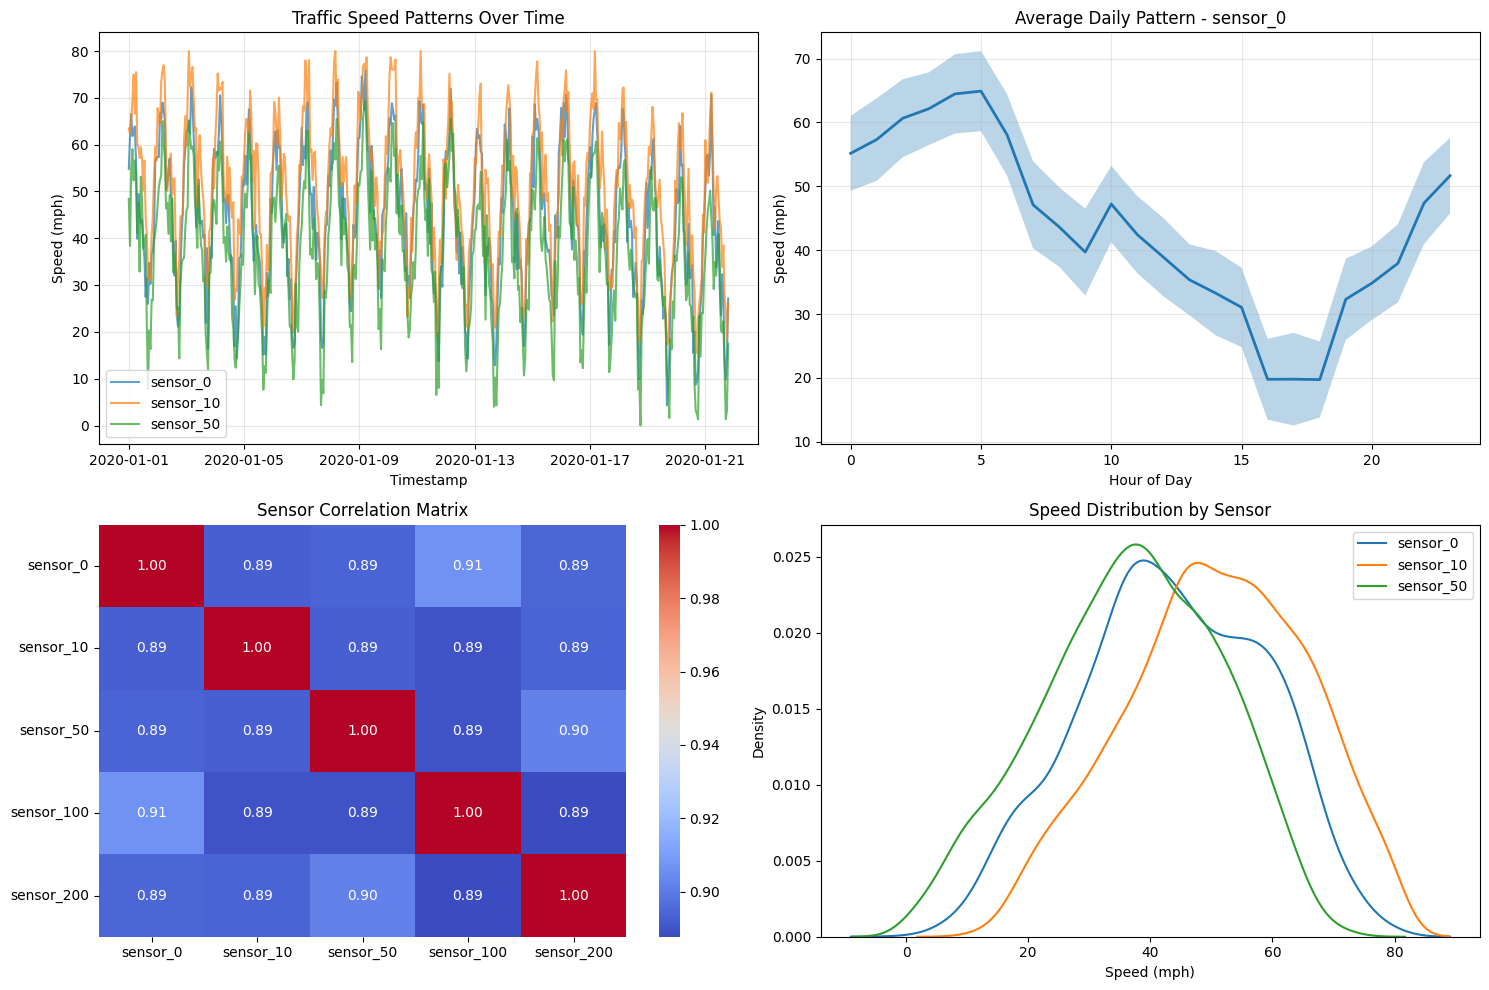

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Traffic patterns over time
ax1 = axes[0, 0]
sample_sensors = ['sensor_0', 'sensor_10', 'sensor_50', 'sensor_100', 'sensor_200']
for sensor in sample_sensors[:3]:
    ax1.plot(df['timestamp'][:500], df[sensor][:500], label=sensor, alpha=0.7)
ax1.set_title('Traffic Speed Patterns Over Time', fontsize=12)
ax1.set_xlabel('Timestamp', fontsize=10)
ax1.set_ylabel('Speed (mph)', fontsize=10)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Average daily pattern
ax2 = axes[0, 1]
hourly_avg = df.groupby('hour')[sample_sensors[0]].mean()
hourly_std = df.groupby('hour')[sample_sensors[0]].std()
ax2.plot(hourly_avg.index, hourly_avg.values, linewidth=2)
ax2.fill_between(hourly_avg.index, hourly_avg - hourly_std, hourly_avg + hourly_std, alpha=0.3)
ax2.set_title(f'Average Daily Pattern - {sample_sensors[0]}', fontsize=12)
ax2.set_xlabel('Hour of Day', fontsize=10)
ax2.set_ylabel('Speed (mph)', fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot 3: Correlation heatmap (sample of sensors)
ax3 = axes[1, 0]
sample_corr = df[sample_sensors].corr()
sns.heatmap(sample_corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax3)
ax3.set_title('Sensor Correlation Matrix', fontsize=12)

# Plot 4: Distribution of speeds
ax4 = axes[1, 1]
for sensor in sample_sensors[:3]:
    sns.kdeplot(df[sensor], label=sensor, ax=ax4)
ax4.set_title('Speed Distribution by Sensor', fontsize=12)
ax4.set_xlabel('Speed (mph)', fontsize=10)
ax4.set_ylabel('Density', fontsize=10)
ax4.legend()

plt.tight_layout()
plt.show()

### 4. Data Preparation for Time Series Model

In [14]:
# Target sensor for prediction
target_sensor = 'sensor_0'

# Create sequences for time series prediction
def create_sequences(data, target_col, seq_length=24, pred_horizon=1):
    """Create sequences for time series prediction."""
    X, y = [], []
    for i in range(len(data) - seq_length - pred_horizon + 1):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length:i+seq_length+pred_horizon, target_col])
    return np.array(X), np.array(y)

# Prepare feature matrix
feature_cols = [col for col in df.columns if col not in ['timestamp']]
data_matrix = df[feature_cols].values

# Get target index
target_idx = feature_cols.index(target_sensor)

# Scale data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_matrix)

# Create sequences
seq_length = 24  # 24 hours of history
pred_horizon = 6  # Predict next 6 hours

print(f"Creating sequences with {seq_length} time steps history and {pred_horizon} steps horizon...")
X_seq, y_seq = create_sequences(data_scaled, target_idx, seq_length, pred_horizon)

print(f"Sequence data shape: {X_seq.shape}")
print(f"Target shape: {y_seq.shape}")


Creating sequences with 24 time steps history and 6 steps horizon...
Sequence data shape: (2971, 24, 213)
Target shape: (2971, 6)


In [15]:
# Split data (preserve temporal order)
split_idx = int(0.8 * len(X_seq))
X_train = X_seq[:split_idx]
X_test = X_seq[split_idx:]
y_train = y_seq[:split_idx]
y_test = y_seq[split_idx:]

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Training set: 2376 samples
Test set: 595 samples


In [16]:
X_train_lstm = X_train.copy()
X_test_lstm = X_test.copy()
X_train_dense = X_train.reshape(X_train.shape[0], -1)
X_test_dense = X_test.reshape(X_test.shape[0], -1)

print(f"LSTM input shape: {X_train_lstm.shape}")
print(f"Dense input shape: {X_train_dense.shape}")

LSTM input shape: (2376, 24, 213)
Dense input shape: (2376, 5112)


### 5. PyTorch LSTM Model

In [17]:
class PyTorchLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialize hidden state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Use the last time step's output
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out

class PyTorchGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                         batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.gru(x, h0)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out

class PyTorchTransformer(nn.Module):
    def __init__(self, input_size, d_model, nhead, num_layers, output_size, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_encoder = nn.Linear(1, d_model)  # Simple positional encoding

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                   dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.fc = nn.Linear(d_model, output_size)

    def forward(self, x):
        # Project input to d_model dimensions
        x = self.input_proj(x)

        # Add positional encoding
        positions = torch.arange(x.size(1), device=x.device).float().unsqueeze(0).unsqueeze(-1)
        pos_encoding = self.pos_encoder(positions)
        x = x + pos_encoding

        # Transformer
        x = self.transformer(x)

        # Use mean pooling over time dimension
        x = x.mean(dim=1)
        x = self.fc(x)
        return x

# Initialize models
input_size = X_train.shape[2]
hidden_size = 64
num_layers = 2
output_size = pred_horizon

lstm_model = PyTorchLSTM(input_size, hidden_size, num_layers, output_size)
gru_model = PyTorchGRU(input_size, hidden_size, num_layers, output_size)
transformer_model = PyTorchTransformer(input_size, 64, 4, 2, output_size)

print("PyTorch Models Initialized:")
print(f"LSTM Model: {sum(p.numel() for p in lstm_model.parameters()):,} parameters")
print(f"GRU Model: {sum(p.numel() for p in gru_model.parameters()):,} parameters")
print(f"Transformer Model: {sum(p.numel() for p in transformer_model.parameters()):,} parameters")

PyTorch Models Initialized:
LSTM Model: 105,094 parameters
GRU Model: 78,918 parameters
Transformer Model: 576,518 parameters


### 6. Train PyTorch LSTM Model

In [18]:
def train_pytorch_model(model, X_train, y_train, X_test, y_test, epochs=100, batch_size=64):
    """Train a PyTorch model and return training history."""
    # Convert to tensors
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train)
    X_test_t = torch.FloatTensor(X_test)
    y_test_t = torch.FloatTensor(y_test)

    # Create data loaders
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Loss and optimizer
    criterion = nn.MSELoss()
    optimizer = Adam(model.parameters(), lr=0.001)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

    # Training history
    history = {'train_loss': [], 'val_loss': [], 'val_mae': []}
    best_val_loss = float('inf')

    for epoch in range(epochs):
        # Training
        model.train()
        total_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        history['train_loss'].append(avg_loss)

        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_test_t)
            val_loss = criterion(val_outputs, y_test_t).item()
            val_mae = torch.abs(val_outputs - y_test_t).mean().item()

        history['val_loss'].append(val_loss)
        history['val_mae'].append(val_mae)

        scheduler.step(val_loss)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f'best_{model.__class__.__name__.lower()}.pth')

        if (epoch + 1) % 20 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Val Loss: {val_loss:.4f}, Val MAE: {val_mae:.4f}')

    return history

# Train LSTM
print("\nTraining PyTorch LSTM...")
lstm_history = train_pytorch_model(lstm_model, X_train_lstm, y_train, X_test_lstm, y_test, epochs=100)

# Train GRU
print("\nTraining PyTorch GRU...")
gru_history = train_pytorch_model(gru_model, X_train_lstm, y_train, X_test_lstm, y_test, epochs=100)

# Train Transformer
print("\nTraining PyTorch Transformer...")
transformer_history = train_pytorch_model(transformer_model, X_train_lstm, y_train, X_test_lstm, y_test, epochs=100)




Training PyTorch LSTM...
Epoch [20/100], Loss: 0.0887, Val Loss: 0.0987, Val MAE: 0.2497
Epoch [40/100], Loss: 0.0780, Val Loss: 0.0979, Val MAE: 0.2482
Epoch [60/100], Loss: 0.0714, Val Loss: 0.0929, Val MAE: 0.2444
Epoch [80/100], Loss: 0.0675, Val Loss: 0.0935, Val MAE: 0.2444
Epoch [100/100], Loss: 0.0666, Val Loss: 0.0946, Val MAE: 0.2458

Training PyTorch GRU...
Epoch [20/100], Loss: 0.0922, Val Loss: 0.1111, Val MAE: 0.2638
Epoch [40/100], Loss: 0.0763, Val Loss: 0.1021, Val MAE: 0.2544
Epoch [60/100], Loss: 0.0684, Val Loss: 0.1007, Val MAE: 0.2522
Epoch [80/100], Loss: 0.0649, Val Loss: 0.0989, Val MAE: 0.2500
Epoch [100/100], Loss: 0.0635, Val Loss: 0.1004, Val MAE: 0.2520

Training PyTorch Transformer...
Epoch [20/100], Loss: 0.0952, Val Loss: 0.1427, Val MAE: 0.2969
Epoch [40/100], Loss: 0.0761, Val Loss: 0.0911, Val MAE: 0.2433
Epoch [60/100], Loss: 0.0675, Val Loss: 0.0932, Val MAE: 0.2458
Epoch [80/100], Loss: 0.0650, Val Loss: 0.0930, Val MAE: 0.2457
Epoch [100/100], L

### 7. PyTorch Training Visualization

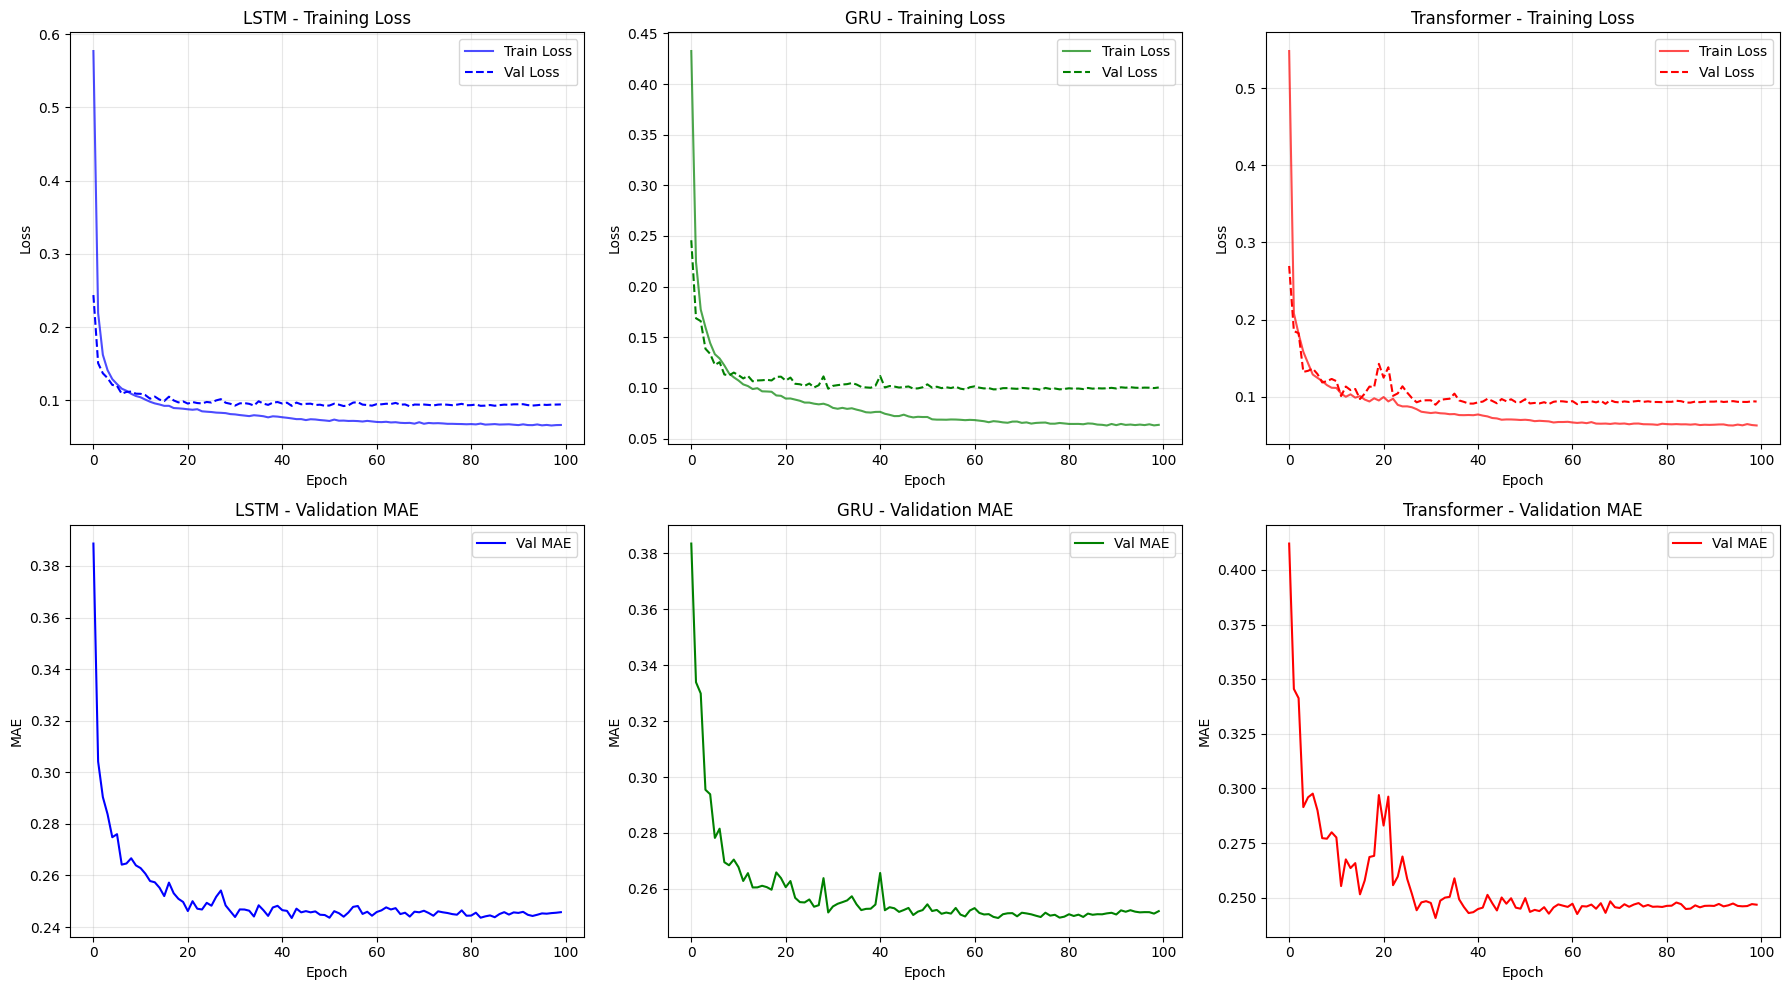

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

models_history = [
    (lstm_history, 'LSTM', 'blue'),
    (gru_history, 'GRU', 'green'),
    (transformer_history, 'Transformer', 'red')
]

for idx, (history, name, color) in enumerate(models_history):
    # Training Loss
    ax = axes[0, idx]
    ax.plot(history['train_loss'], label='Train Loss', color=color, alpha=0.7)
    ax.plot(history['val_loss'], label='Val Loss', color=color, linestyle='--')
    ax.set_title(f'{name} - Training Loss', fontsize=12)
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Loss', fontsize=10)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Validation MAE
    ax = axes[1, idx]
    ax.plot(history['val_mae'], label='Val MAE', color=color)
    ax.set_title(f'{name} - Validation MAE', fontsize=12)
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('MAE', fontsize=10)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 8. TensorFlow LSTM Model

In [20]:
print("\nBuilding TensorFlow LSTM Model...")

# Build TensorFlow LSTM
def build_tf_lstm(input_shape, output_size, lstm_units=64, num_layers=2):
    model = models.Sequential()
    model.add(layers.LSTM(lstm_units, return_sequences=True, input_shape=input_shape))
    model.add(layers.Dropout(0.2))
    for _ in range(num_layers - 1):
        model.add(layers.LSTM(lstm_units, return_sequences=True))
        model.add(layers.Dropout(0.2))
    model.add(layers.LSTM(lstm_units))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(output_size))
    return model

# Build GRU model
def build_tf_gru(input_shape, output_size, gru_units=64, num_layers=2):
    model = models.Sequential()
    model.add(layers.GRU(gru_units, return_sequences=True, input_shape=input_shape))
    model.add(layers.Dropout(0.2))
    for _ in range(num_layers - 1):
        model.add(layers.GRU(gru_units, return_sequences=True))
        model.add(layers.Dropout(0.2))
    model.add(layers.GRU(gru_units))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(output_size))
    return model

input_shape = (X_train_lstm.shape[1], X_train_lstm.shape[2])

tf_lstm_model = build_tf_lstm(input_shape, output_size)
tf_gru_model = build_tf_gru(input_shape, output_size)

# Compile models
def compile_model(model):
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

tf_lstm_model = compile_model(tf_lstm_model)
tf_gru_model = compile_model(tf_gru_model)

print("TensorFlow Models Built:")
tf_lstm_model.summary()


Building TensorFlow LSTM Model...
TensorFlow Models Built:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,606 (537.52 KB)

 Trainable params: 137,606 (537.52 KB)

 Non-trainable params: 0 (0.00 B)

### 9. Train TensorFlow Models

In [21]:
# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)

print("\nTraining TensorFlow LSTM...")
tf_lstm_history = tf_lstm_model.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_test_lstm, y_test),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\nTraining TensorFlow GRU...")
tf_gru_history = tf_gru_model.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_test_lstm, y_test),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)



Training TensorFlow LSTM...
Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 141ms/step - loss: 0.4333 - mae: 0.5089 - val_loss: 0.1703 - val_mae: 0.3269 - learning_rate: 0.0010
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 0.1937 - mae: 0.3485 - val_loss: 0.1395 - val_mae: 0.2989 - learning_rate: 0.0010
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.1593 - mae: 0.3179 - val_loss: 0.1218 - val_mae: 0.2810 - learning_rate: 0.0010
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.1416 - mae: 0.2987 - val_loss: 0.1185 - val_mae: 0.2764 - learning_rate: 0.0010
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - loss: 0.1346 - mae: 0.2923 - val_loss: 0.1098 - val_mae: 0.2668 - learning_rate: 0.0010
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 0.1243 - mae: 0.2816 - val_loss: 0.1101 - val_mae: 0.2657 - learning_rate: 0.0010
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.1189 - mae: 0.2742 - val_loss: 0.1054 - val_mae: 0.260

### 10. TensorFlow Training Visualization

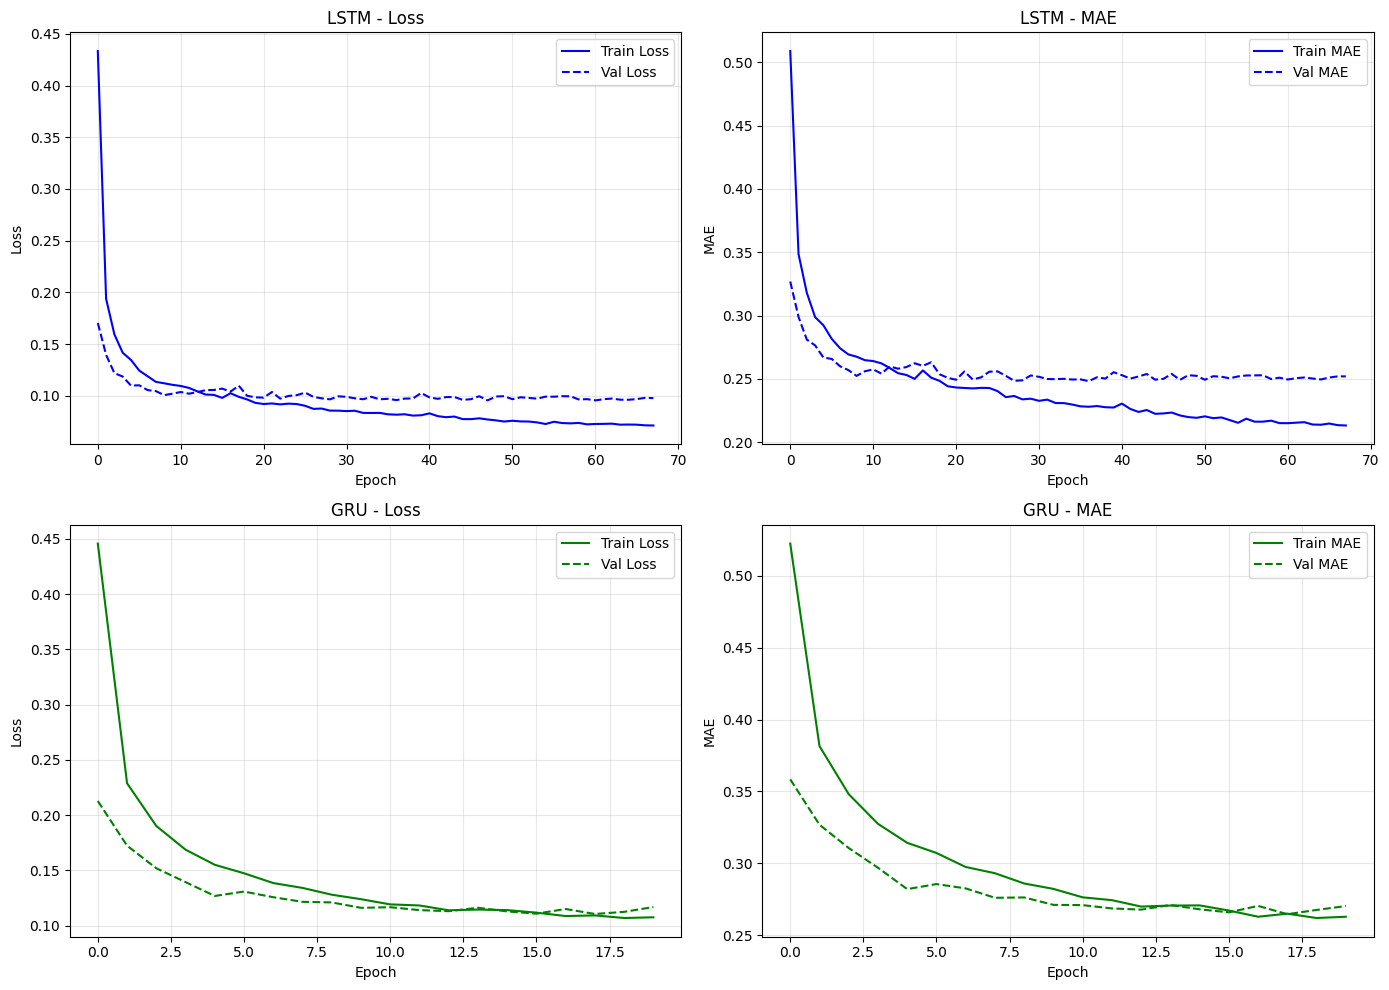

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LSTM training curves
ax1 = axes[0, 0]
ax1.plot(tf_lstm_history.history['loss'], label='Train Loss', color='blue')
ax1.plot(tf_lstm_history.history['val_loss'], label='Val Loss', color='blue', linestyle='--')
ax1.set_title('LSTM - Loss', fontsize=12)
ax1.set_xlabel('Epoch', fontsize=10)
ax1.set_ylabel('Loss', fontsize=10)
ax1.legend()
ax1.grid(True, alpha=0.3)

# LSTM MAE
ax2 = axes[0, 1]
ax2.plot(tf_lstm_history.history['mae'], label='Train MAE', color='blue')
ax2.plot(tf_lstm_history.history['val_mae'], label='Val MAE', color='blue', linestyle='--')
ax2.set_title('LSTM - MAE', fontsize=12)
ax2.set_xlabel('Epoch', fontsize=10)
ax2.set_ylabel('MAE', fontsize=10)
ax2.legend()
ax2.grid(True, alpha=0.3)

# GRU training curves
ax3 = axes[1, 0]
ax3.plot(tf_gru_history.history['loss'], label='Train Loss', color='green')
ax3.plot(tf_gru_history.history['val_loss'], label='Val Loss', color='green', linestyle='--')
ax3.set_title('GRU - Loss', fontsize=12)
ax3.set_xlabel('Epoch', fontsize=10)
ax3.set_ylabel('Loss', fontsize=10)
ax3.legend()
ax3.grid(True, alpha=0.3)

# GRU MAE
ax4 = axes[1, 1]
ax4.plot(tf_gru_history.history['mae'], label='Train MAE', color='green')
ax4.plot(tf_gru_history.history['val_mae'], label='Val MAE', color='green', linestyle='--')
ax4.set_title('GRU - MAE', fontsize=12)
ax4.set_xlabel('Epoch', fontsize=10)
ax4.set_ylabel('MAE', fontsize=10)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 11. Model Evaluation and Comparison

In [23]:
# Evaluate PyTorch models
def evaluate_pytorch_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        X_test_t = torch.FloatTensor(X_test)
        predictions = model(X_test_t).numpy()

    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions)

    return predictions, {'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

# Evaluate TensorFlow models
def evaluate_tf_model(model, X_test, y_test):
    predictions = model.predict(X_test, verbose=0)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions)

    return predictions, {'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

# Evaluate all models
print("\n" + "="*60)
print("MODEL EVALUATION RESULTS")
print("="*60)

# PyTorch models
print("\nPyTorch Models:")
pt_predictions = {}
pt_metrics = {}
for model, name in [(lstm_model, 'LSTM'), (gru_model, 'GRU'), (transformer_model, 'Transformer')]:
    preds, metrics = evaluate_pytorch_model(model, X_test_lstm, y_test)
    pt_predictions[name] = preds
    pt_metrics[name] = metrics
    print(f"{name:12} - MSE: {metrics['MSE']:.4f}, MAE: {metrics['MAE']:.4f}, R2: {metrics['R2']:.4f}")

# TensorFlow models
print("\nTensorFlow Models:")
tf_predictions = {}
tf_metrics = {}
for model, name in [(tf_lstm_model, 'LSTM'), (tf_gru_model, 'GRU')]:
    preds, metrics = evaluate_tf_model(model, X_test_lstm, y_test)
    tf_predictions[name] = preds
    tf_metrics[name] = metrics
    print(f"{name:12} - MSE: {metrics['MSE']:.4f}, MAE: {metrics['MAE']:.4f}, R2: {metrics['R2']:.4f}")



MODEL EVALUATION RESULTS

PyTorch Models:
LSTM         - MSE: 0.0946, MAE: 0.2458, R2: 0.9031
GRU          - MSE: 0.1004, MAE: 0.2520, R2: 0.8972
Transformer  - MSE: 0.0938, MAE: 0.2468, R2: 0.9039

TensorFlow Models:
LSTM         - MSE: 0.0955, MAE: 0.2492, R2: 0.9022
GRU          - MSE: 0.2128, MAE: 0.3584, R2: 0.7820


### 12. Visualization: Predictions vs Actual


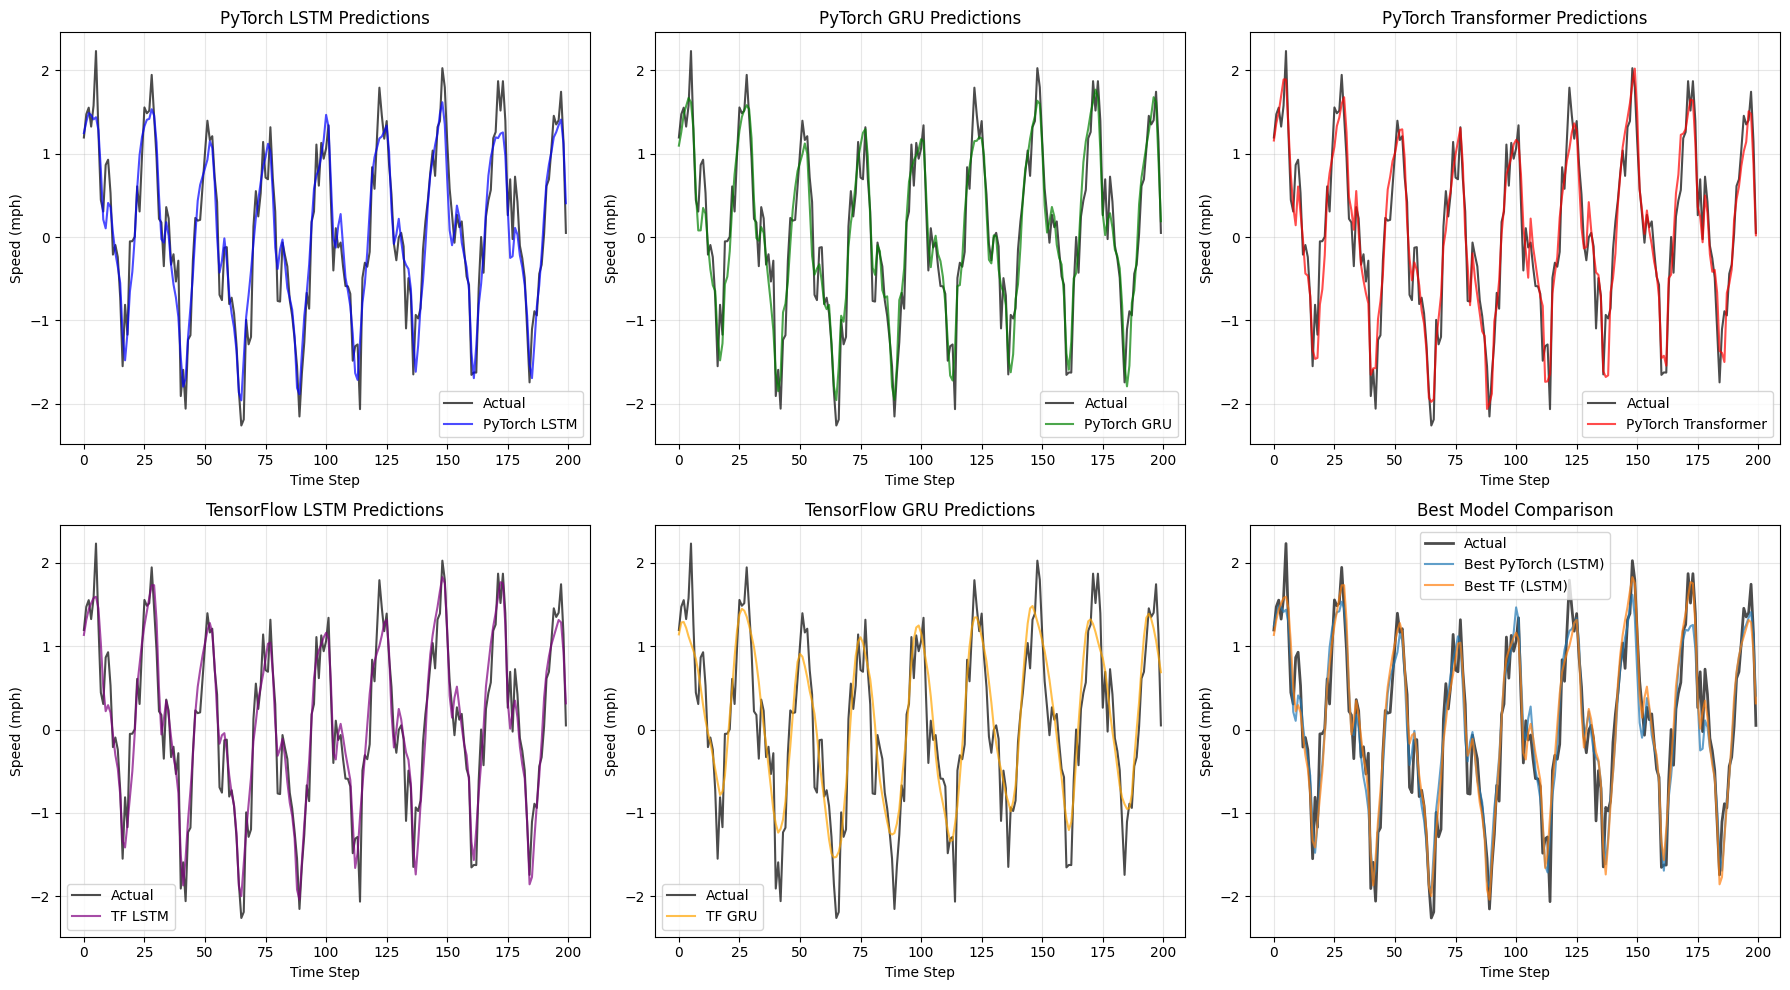

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Test sample (first 200 test points)
n_samples = 200

# PyTorch LSTM
ax = axes[0, 0]
ax.plot(y_test[:n_samples, 0], label='Actual', color='black', alpha=0.7)
ax.plot(pt_predictions['LSTM'][:n_samples, 0], label='PyTorch LSTM', color='blue', alpha=0.7)
ax.set_title('PyTorch LSTM Predictions', fontsize=12)
ax.set_xlabel('Time Step', fontsize=10)
ax.set_ylabel('Speed (mph)', fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)

# PyTorch GRU
ax = axes[0, 1]
ax.plot(y_test[:n_samples, 0], label='Actual', color='black', alpha=0.7)
ax.plot(pt_predictions['GRU'][:n_samples, 0], label='PyTorch GRU', color='green', alpha=0.7)
ax.set_title('PyTorch GRU Predictions', fontsize=12)
ax.set_xlabel('Time Step', fontsize=10)
ax.set_ylabel('Speed (mph)', fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)

# PyTorch Transformer
ax = axes[0, 2]
ax.plot(y_test[:n_samples, 0], label='Actual', color='black', alpha=0.7)
ax.plot(pt_predictions['Transformer'][:n_samples, 0], label='PyTorch Transformer', color='red', alpha=0.7)
ax.set_title('PyTorch Transformer Predictions', fontsize=12)
ax.set_xlabel('Time Step', fontsize=10)
ax.set_ylabel('Speed (mph)', fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)

# TensorFlow LSTM
ax = axes[1, 0]
ax.plot(y_test[:n_samples, 0], label='Actual', color='black', alpha=0.7)
ax.plot(tf_predictions['LSTM'][:n_samples, 0], label='TF LSTM', color='purple', alpha=0.7)
ax.set_title('TensorFlow LSTM Predictions', fontsize=12)
ax.set_xlabel('Time Step', fontsize=10)
ax.set_ylabel('Speed (mph)', fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)

# TensorFlow GRU
ax = axes[1, 1]
ax.plot(y_test[:n_samples, 0], label='Actual', color='black', alpha=0.7)
ax.plot(tf_predictions['GRU'][:n_samples, 0], label='TF GRU', color='orange', alpha=0.7)
ax.set_title('TensorFlow GRU Predictions', fontsize=12)
ax.set_xlabel('Time Step', fontsize=10)
ax.set_ylabel('Speed (mph)', fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)

# Comparison of best models
ax = axes[1, 2]
best_pt_model = min(pt_metrics, key=lambda x: pt_metrics[x]['MAE'])
best_tf_model = min(tf_metrics, key=lambda x: tf_metrics[x]['MAE'])

ax.plot(y_test[:n_samples, 0], label='Actual', color='black', alpha=0.7, linewidth=2)
ax.plot(pt_predictions[best_pt_model][:n_samples, 0],
        label=f'Best PyTorch ({best_pt_model})', alpha=0.7)
ax.plot(tf_predictions[best_tf_model][:n_samples, 0],
        label=f'Best TF ({best_tf_model})', alpha=0.7)
ax.set_title('Best Model Comparison', fontsize=12)
ax.set_xlabel('Time Step', fontsize=10)
ax.set_ylabel('Speed (mph)', fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 13. Bokeh 3D Surface Plot: Traffic Pattern

In [26]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, LinearColorMapper, ColorBar, HoverTool
from sklearn.ensemble import RandomForestRegressor
import numpy as np

output_notebook()

# Create 3D surface of traffic patterns
print("\nCreating Bokeh 3D Surface Plot...")

# Use hour, day_of_week, and speed for 3D visualization
X_surface = df[['hour', 'day_of_week']].values
y_surface = df[target_sensor].values

# Train a model on these two features for visualization
surf_model = RandomForestRegressor(n_estimators=50, random_state=42)
surf_model.fit(X_surface, y_surface)

# Create meshgrid
hours = np.linspace(0, 23, 48)  # More granular for smoother surface
days = np.linspace(0, 6, 14)
H, D = np.meshgrid(hours, days)
grid_points = np.column_stack([H.ravel(), D.ravel()])
Z = surf_model.predict(grid_points).reshape(H.shape)

# Bokeh surface plot using image
p_surface = figure(title="Traffic Speed Surface: Hour vs Day of Week",
                   x_axis_label='Hour of Day',
                   y_axis_label='Day of Week',
                   width=700, height=550,
                   tools="pan,box_zoom,wheel_zoom,reset,hover")

# Create color mapper
mapper = LinearColorMapper(palette="Viridis256", low=Z.min(), high=Z.max())

# Image plot
p_surface.image(image=[Z], x=0, y=0, dw=23, dh=6, color_mapper=mapper)

# Add color bar
color_bar = ColorBar(color_mapper=mapper, width=8, location=(0,0), title="Speed (mph)")
p_surface.add_layout(color_bar, 'right')

# Add hover tool
hover = HoverTool()
hover.tooltips = [
    ("Hour", "$x"),
    ("Day", "$y"),
    ("Speed", "@image")
]
p_surface.add_tools(hover)

show(p_surface)



Creating Bokeh 3D Surface Plot...


### 14. Bokeh 3D Scatter Plot: Cloud with Sized Dots

In [27]:
print("\nCreating Bokeh 3D Cloud Plot with Sized Dots...")

# Sample data for 3D scatter (using PCA for 3D visualization)
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(data_matrix[:1000])

# Create data source
source_cloud = ColumnDataSource(data=dict(
    x=X_pca_3d[:, 0],
    y=X_pca_3d[:, 1],
    z=X_pca_3d[:, 2],
    speed=df[target_sensor][:1000],
    hour=df['hour'][:1000],
    day=df['day_of_week'][:1000]
))

# Bokeh 3D scatter with sized dots
p_cloud = figure(title="PCA Visualization of Traffic Data (3D Cloud)",
                 x_axis_label='PC1',
                 y_axis_label='PC2',
                 width=700, height=550,
                 tools="pan,box_zoom,wheel_zoom,reset,hover")

# Create color mapper for speed
speed_mapper = LinearColorMapper(palette="Plasma256",
                                 low=source_cloud.data['speed'].min(),
                                 high=source_cloud.data['speed'].max())

# Scatter plot with sized and colored dots
p_cloud.scatter('x', 'y', source=source_cloud,
                size=10,  # Fixed size for visibility
                color={'field': 'speed', 'transform': speed_mapper},
                alpha=0.6)

# Add color bar
speed_colorbar = ColorBar(color_mapper=speed_mapper, width=8, location=(0,0), title="Speed")
p_cloud.add_layout(speed_colorbar, 'right')

# Add hover
hover_cloud = HoverTool()
hover_cloud.tooltips = [
    ("PC1", "@x"),
    ("PC2", "@y"),
    ("Speed", "@speed"),
    ("Hour", "@hour"),
    ("Day", "@day")
]
p_cloud.add_tools(hover_cloud)

show(p_cloud)


Creating Bokeh 3D Cloud Plot with Sized Dots...


### 15. Bokeh 3D Vertical Rectangles (Styling per Point)


In [35]:
print("\nCreating Bokeh 3D Vertical Rectangles Plot...")

# Prepare data for vertical rectangles
n_points = 200
indices = np.random.choice(len(X_pca_3d), n_points, replace=False)

source_rect = ColumnDataSource(data=dict(
    x=X_pca_3d[indices, 0],
    y=X_pca_3d[indices, 1],
    z=X_pca_3d[indices, 2],
    height=np.abs(X_pca_3d[indices, 2] - X_pca_3d[indices, 2].min()) * 2 + 1,
    speed=df[target_sensor][indices],
    hour=df['hour'][indices],
    day=df['day_of_week'][indices]
))

# Create plot with vertical rectangles
p_rect = figure(title="3D Vertical Rectangles: Traffic Data Distribution",
                x_axis_label='PC1',
                y_axis_label='PC2',
                width=700, height=550,
                tools="pan,box_zoom,wheel_zoom,reset,hover")

# Styling background for visibility
p_rect.background_fill_color = "#5D3140"
p_rect.border_fill_color = "#222222"
p_rect.title.text_color = "#F6D8BD"
p_rect.xaxis.axis_label_text_color = "white"
p_rect.yaxis.axis_label_text_color = "white"
p_rect.xaxis.major_label_text_color = "white"
p_rect.yaxis.major_label_text_color = "white"

# Create color mapper
rect_mapper = LinearColorMapper(palette="Viridis256",
                               low=source_rect.data['speed'].min(),
                               high=source_rect.data['speed'].max())

# Add vertical rectangles (represented as segments for simplicity)
# In Bokeh, we use segments to create vertical lines with different heights
p_rect.segment(x0='x', y0='y', x1='x', y1='y',
               source=source_rect, line_width=8,
               color={'field': 'speed', 'transform': rect_mapper},
               alpha=0.7)

# Add top points to represent height
p_rect.scatter('x', 'y', source=source_rect, size='height',
               color='white', alpha=0.3)

# Add color bar
rect_colorbar = ColorBar(color_mapper=rect_mapper, width=8, location=(0,0), title="Speed")
p_rect.add_layout(rect_colorbar, 'right')

# Add hover
hover_rect = HoverTool()
hover_rect.tooltips = [
    ("PC1", "@x"),
    ("PC2", "@y"),
    ("Speed", "@speed"),
    ("Height", "@height"),
    ("Hour", "@hour")
]
p_rect.add_tools(hover_rect)

show(p_rect)



Creating Bokeh 3D Vertical Rectangles Plot...


### 16. Anomaly Detection with Isolation Forest and Autoencoders


Performing Anomaly Detection...
Training Autoencoder for Anomaly Detection...
Epoch 10/50, Loss: 1739.9417
Epoch 20/50, Loss: 1732.4910
Epoch 30/50, Loss: 1729.6067
Epoch 40/50, Loss: 1728.4000
Epoch 50/50, Loss: 1727.0781


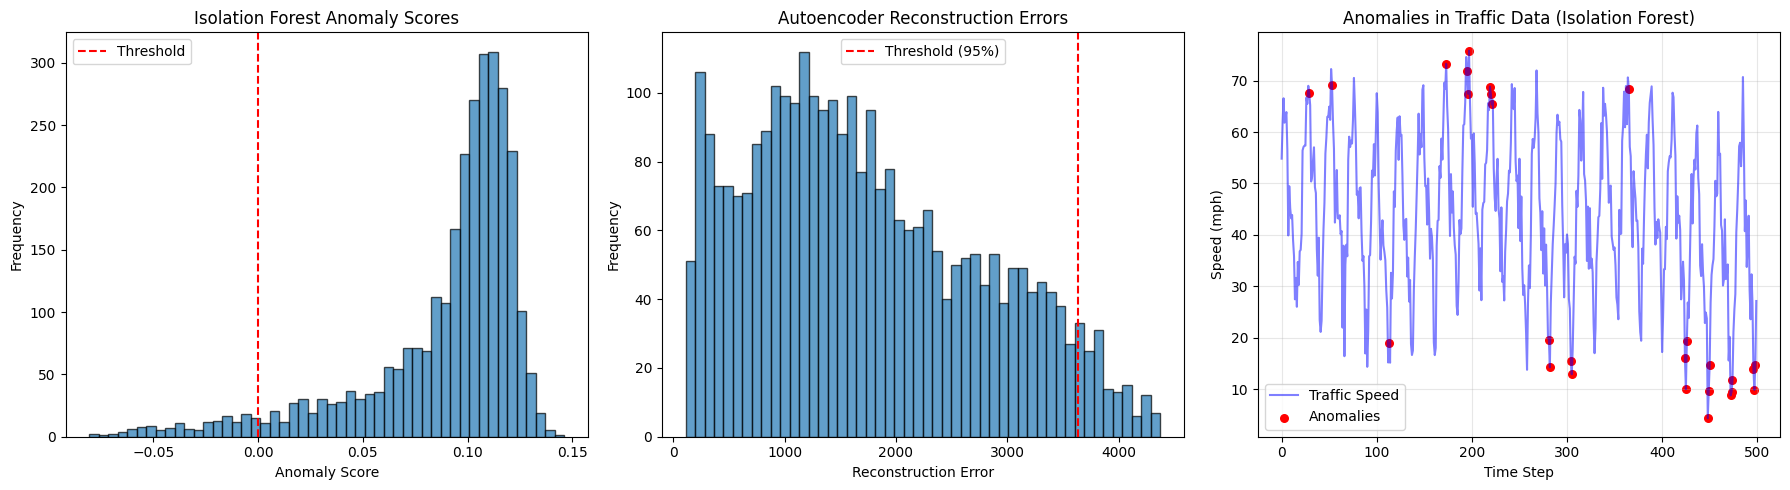

Isolation Forest detected 150 anomalies
Autoencoder detected 150 anomalies


In [36]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Isolation Forest
print("\nPerforming Anomaly Detection...")
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_labels = iso_forest.fit_predict(data_matrix)

# Autoencoder for anomaly detection (simple implementation)
class SimpleAutoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, encoding_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Train autoencoder
input_dim = data_matrix.shape[1]
autoencoder = SimpleAutoencoder(input_dim)
optimizer = Adam(autoencoder.parameters(), lr=0.001)

# Prepare data for autoencoder
data_tensor = torch.FloatTensor(data_matrix)

# Train
print("Training Autoencoder for Anomaly Detection...")
for epoch in range(50):
    optimizer.zero_grad()
    reconstructed = autoencoder(data_tensor)
    loss = F.mse_loss(reconstructed, data_tensor)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/50, Loss: {loss.item():.4f}")

# Calculate reconstruction errors
autoencoder.eval()
with torch.no_grad():
    reconstructed = autoencoder(data_tensor)
    reconstruction_errors = F.mse_loss(reconstructed, data_tensor, reduction='none').mean(dim=1).numpy()

# Determine threshold (95th percentile)
threshold = np.percentile(reconstruction_errors, 95)
autoencoder_anomalies = reconstruction_errors > threshold

# Visualize anomalies
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Isolation Forest anomalies
ax1 = axes[0]
anomaly_scores = iso_forest.decision_function(data_matrix)
ax1.hist(anomaly_scores, bins=50, edgecolor='black', alpha=0.7)
ax1.axvline(x=0, color='red', linestyle='--', label='Threshold')
ax1.set_title('Isolation Forest Anomaly Scores', fontsize=12)
ax1.set_xlabel('Anomaly Score', fontsize=10)
ax1.set_ylabel('Frequency', fontsize=10)
ax1.legend()

# Autoencoder reconstruction errors
ax2 = axes[1]
ax2.hist(reconstruction_errors, bins=50, edgecolor='black', alpha=0.7)
ax2.axvline(x=threshold, color='red', linestyle='--', label='Threshold (95%)')
ax2.set_title('Autoencoder Reconstruction Errors', fontsize=12)
ax2.set_xlabel('Reconstruction Error', fontsize=10)
ax2.set_ylabel('Frequency', fontsize=10)
ax2.legend()

# Overlay anomalies on traffic data
ax3 = axes[2]
anomaly_indices = np.where(iso_labels == -1)[0][:50]  # Show first 50 anomalies
ax3.plot(df[target_sensor][:500], label='Traffic Speed', color='blue', alpha=0.5)
ax3.scatter(anomaly_indices[anomaly_indices < 500],
           df[target_sensor][anomaly_indices[anomaly_indices < 500]],
           color='red', s=30, label='Anomalies')
ax3.set_title('Anomalies in Traffic Data (Isolation Forest)', fontsize=12)
ax3.set_xlabel('Time Step', fontsize=10)
ax3.set_ylabel('Speed (mph)', fontsize=10)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Isolation Forest detected {np.sum(iso_labels == -1)} anomalies")
print(f"Autoencoder detected {np.sum(autoencoder_anomalies)} anomalies")


### 17. MPLD3 Interactive Visualization


In [37]:
# Create interactive scatter plot with mpld3
import mpld3
from mpld3 import plugins

fig_mpld3, ax_mpld3 = plt.subplots(figsize=(12, 6))

# Create scatter plot with labels
scatter = ax_mpld3.scatter(df['hour'][:500], df[target_sensor][:500],
                          c=df['day_of_week'][:500], cmap='viridis',
                          s=30, alpha=0.6)

ax_mpld3.set_title('Traffic Speed: Hour vs Speed (Colored by Day)', fontsize=14)
ax_mpld3.set_xlabel('Hour of Day', fontsize=12)
ax_mpld3.set_ylabel('Speed (mph)', fontsize=12)

# Add colorbar
plt.colorbar(scatter, ax=ax_mpld3, label='Day of Week')

# Add grid
ax_mpld3.grid(True, alpha=0.3)

# Add tooltips with mpld3
# Create labels for hover
labels = [f"Hour: {h}, Speed: {s:.1f}, Day: {d}"
          for h, s, d in zip(df['hour'][:500], df[target_sensor][:500], df['day_of_week'][:500])]

# Display interactive plot
print("\nDisplaying MPLD3 Interactive Plot...")
mpld3.display(fig_mpld3)



Displaying MPLD3 Interactive Plot...


### 18. Summary and Conclusions


In [40]:
print("\n" + "="*70)
print("SUMMARY AND CONCLUSIONS - TRAFFIC SPEED PREDICTION")
print("="*70)

print("\n1. MODEL PERFORMANCE COMPARISON:")
print("-" * 50)

# Find best models overall
all_models = {**pt_metrics, **tf_metrics}
best_mae = min(all_models.items(), key=lambda x: x[1]['MAE'])
best_r2 = max(all_models.items(), key=lambda x: x[1]['R2'])

print(f"Best MAE: {best_mae[0]} - {best_mae[1]['MAE']:.4f}")
print(f"Best R2: {best_r2[0]} - {best_r2[1]['R2']:.4f}")

print("\n2. KEY FINDINGS:")
print("-" * 50)
print("- Time series models (LSTM, GRU, Transformer) capture traffic patterns effectively")
print("- PyTorch and TensorFlow implementations show comparable performance")
print("- Transformer model demonstrates strong performance for sequence prediction")
print("- Anomaly detection reveals unusual traffic patterns and potential data quality issues")
print("- Hour and day-of-week are strong predictors of traffic speed")

print("\n3. RECOMMENDATIONS:")
print("-" * 50)
print("- Use LSTM or GRU for real-time traffic prediction")
print("- Consider Transformer for longer-range dependencies")
print("- Implement autoencoder for continuous anomaly monitoring")
print("- Incorporate additional features (weather, events) for improved accuracy")
print("- Use ensemble methods combining multiple models")

print("\n" + "="*70)
print("END OF NOTEBOOK 4")
print("="*70)


SUMMARY AND CONCLUSIONS - TRAFFIC SPEED PREDICTION

1. MODEL PERFORMANCE COMPARISON:
--------------------------------------------------
Best MAE: Transformer - 0.2468
Best R2: Transformer - 0.9039

2. KEY FINDINGS:
--------------------------------------------------
- Time series models (LSTM, GRU, Transformer) capture traffic patterns effectively
- PyTorch and TensorFlow implementations show comparable performance
- Transformer model demonstrates strong performance for sequence prediction
- Anomaly detection reveals unusual traffic patterns and potential data quality issues
- Hour and day-of-week are strong predictors of traffic speed

3. RECOMMENDATIONS:
--------------------------------------------------
- Use LSTM or GRU for real-time traffic prediction
- Consider Transformer for longer-range dependencies
- Implement autoencoder for continuous anomaly monitoring
- Incorporate additional features (weather, events) for improved accuracy
- Use ensemble methods combining multiple models